In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
os.chdir("..")
print(os.getcwd())
sys.path.append(os.path.abspath(".."))


c:\Users\Administrator\Desktop\crop project\croprecommendationproject


In [2]:
from src.preprocessing import CropPreprocessor

preprocessor = CropPreprocessor()

data = preprocessor.preprocess("data/raw/Crop_recommendation.csv")

Cleaned dataset saved to: data/processed/cleaned_crop_data.csv


In [3]:
X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

In [4]:
#train the knn model
#looks at the 5 closest data points
# model = KNeighborsClassifier(n_neighbors=5)
# model.fit(X_train, y_train)

# #make predictions
# y_pred = model.predict(X_test)

print("\n Testing K values (1 to 20) ")
k_values  = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred_k)
    accuracies.append(acc)
    print(f"  K={k:2d}  →  Accuracy: {acc:.4f}")


 Testing K values (1 to 20) 
  K= 1  →  Accuracy: 0.9864
  K= 2  →  Accuracy: 0.9705
  K= 3  →  Accuracy: 0.9795
  K= 4  →  Accuracy: 0.9818
  K= 5  →  Accuracy: 0.9773
  K= 6  →  Accuracy: 0.9773
  K= 7  →  Accuracy: 0.9818
  K= 8  →  Accuracy: 0.9795
  K= 9  →  Accuracy: 0.9864
  K=10  →  Accuracy: 0.9818
  K=11  →  Accuracy: 0.9864
  K=12  →  Accuracy: 0.9750
  K=13  →  Accuracy: 0.9841
  K=14  →  Accuracy: 0.9750
  K=15  →  Accuracy: 0.9795
  K=16  →  Accuracy: 0.9750
  K=17  →  Accuracy: 0.9795
  K=18  →  Accuracy: 0.9705
  K=19  →  Accuracy: 0.9750
  K=20  →  Accuracy: 0.9705


In [5]:
# #accuracy check
# accuracy = accuracy_score(y_test, y_pred)
# print("Accuracy:", accuracy)


 Best K = 1  (Accuracy: 0.9864)


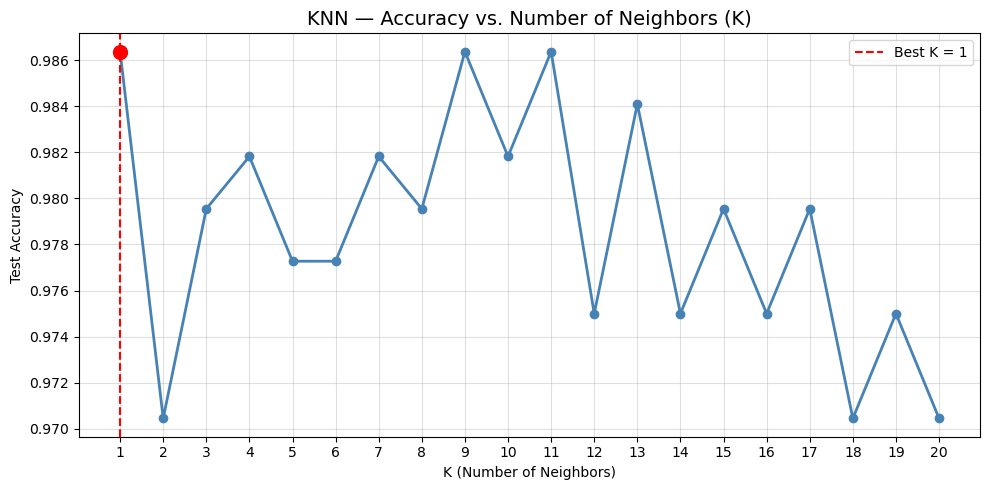

In [6]:
#try diff k values
# for k in range(1, 21):
#     model = KNeighborsClassifier(n_neighbors=k)
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     print(k, accuracy_score(y_test, y_pred))

best_k = k_values[accuracies.index(max(accuracies))]
print(f"\n Best K = {best_k}  (Accuracy: {max(accuracies):.4f})")

plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker="o", color="steelblue", linewidth=2)
plt.axvline(x=best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
plt.scatter([best_k], [max(accuracies)], color="red", zorder=5, s=100)
plt.title("KNN — Accuracy vs. Number of Neighbors (K)", fontsize=14)
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Test Accuracy")
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
#plt.savefig("knn_elbow_curve.png", dpi=150)
plt.show()
#print("Saved: knn_elbow_curve.png")


In [7]:
# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))

In [8]:
print("\n 5-Fold Cross-Validation with Best K ")

import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

X_all_scaled = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

knn_best = KNeighborsClassifier(n_neighbors=best_k)

cv_scores = cross_val_score(
    knn_best,
    X_all_scaled,
    y_all,
    cv=5,
    scoring="accuracy"
)

print(f"CV Scores per fold: {[round(s, 4) for s in cv_scores]}")
print(f"Mean CV Accuracy  : {cv_scores.mean():.4f}")
print(f"Std Deviation     : {cv_scores.std():.4f}")


 5-Fold Cross-Validation with Best K 
CV Scores per fold: [0.9841, 0.9727, 0.9795, 0.9795, 0.9864]
Mean CV Accuracy  : 0.9805
Std Deviation     : 0.0047


In [9]:
print("\nUniform vs Distance-Weighted KNN ")

knn_uniform  = KNeighborsClassifier(n_neighbors=best_k, weights="uniform")
knn_distance = KNeighborsClassifier(n_neighbors=best_k, weights="distance")

knn_uniform.fit(X_train, y_train)
knn_distance.fit(X_train, y_train)

acc_uniform  = accuracy_score(y_test, knn_uniform.predict(X_test))
acc_distance = accuracy_score(y_test, knn_distance.predict(X_test))

print(f"  Uniform  weights → Accuracy: {acc_uniform:.4f}")
print(f"  Distance weights → Accuracy: {acc_distance:.4f}")

# Choose the better model for the rest of the analysis
if acc_distance >= acc_uniform:
    final_model  = knn_distance
    final_weight = "distance"
    final_acc    = acc_distance
else:
    final_model  = knn_uniform
    final_weight = "uniform"
    final_acc    = acc_uniform

print(f"\n Using weights='{final_weight}' for final model  (Accuracy: {final_acc:.4f})")


Uniform vs Distance-Weighted KNN 
  Uniform  weights → Accuracy: 0.9864
  Distance weights → Accuracy: 0.9864

 Using weights='distance' for final model  (Accuracy: 0.9864)



 FINAL KNN MODEL PERFORMANCE 
  K            : 1
  Weights      : distance
  Test Accuracy: 0.9864 (98.64%)

 Classification Report 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       0.95      1.00      0.98        20
           7       1.00      1.00      1.00        20
           8       1.00      0.90      0.95        20
           9       1.00      1.00      1.00        20
          10       0.95      0.95      0.95        20
          11       1.00      0.95      0.97        20
          12       1.00      1.00      1.00        20
          13       0.95      0.95      0.95        20
          14       1.00      1.00      1.00        20
 

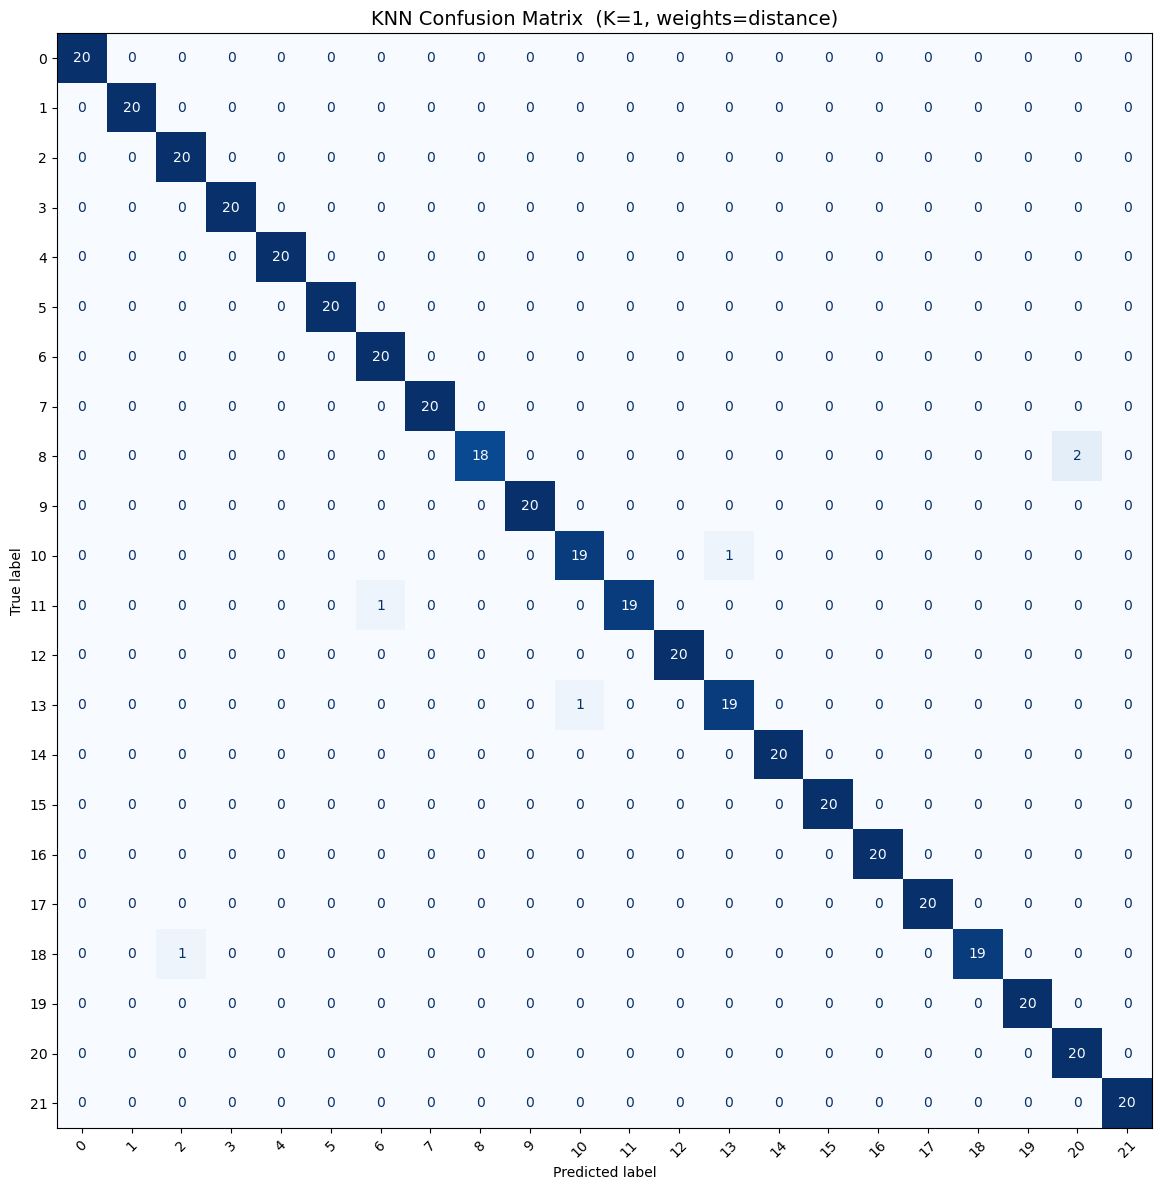

In [10]:
#final model evaluation
y_pred_final = final_model.predict(X_test)

print("\n FINAL KNN MODEL PERFORMANCE ")
print(f"  K            : {best_k}")
print(f"  Weights      : {final_weight}")
print(f"  Test Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")

print("\n Classification Report ")
print(classification_report(y_test, y_pred_final))

# Confusion Matrix 
# Shows which crops the model confuses for each other.
# Each row = actual crop, each column = predicted crop.
# Ideal: a bright diagonal, dark everywhere else.
cm     = confusion_matrix(y_test, y_pred_final, labels=final_model.classes_)
fig, ax = plt.subplots(figsize=(14, 12))
disp   = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title(f"KNN Confusion Matrix  (K={best_k}, weights={final_weight})", fontsize=14)
plt.tight_layout()
#plt.savefig("knn_confusion_matrix.png", dpi=150)
plt.show()
#print("Saved: knn_confusion_matrix.png")

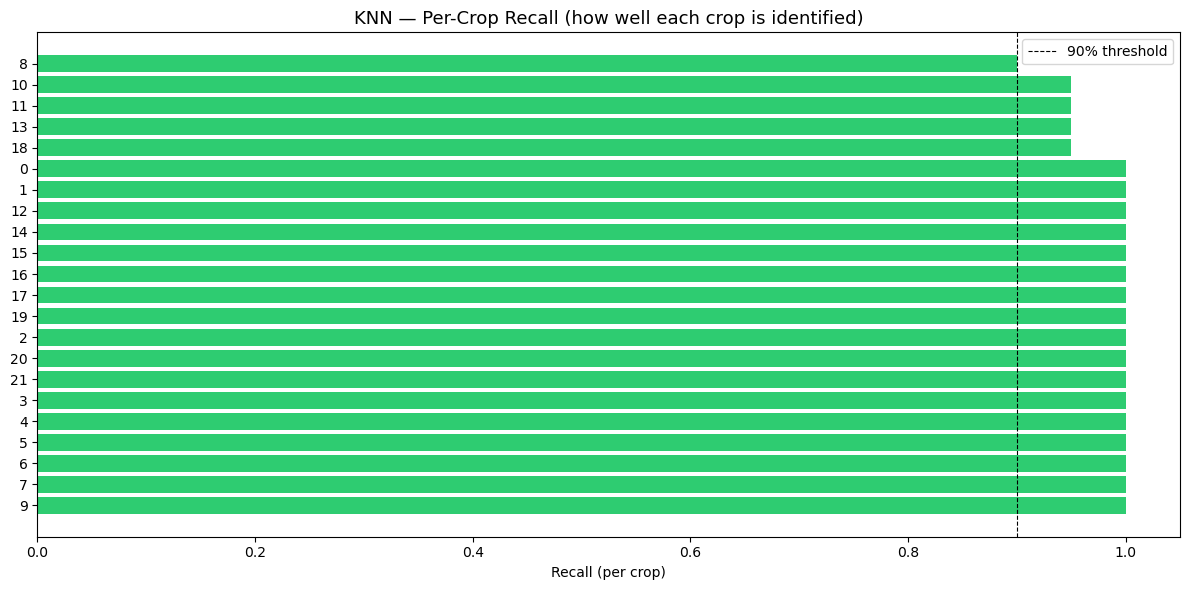

In [11]:
#per class accuracy bar chat
report_dict = classification_report(y_test, y_pred_final, output_dict=True)
classes   = [k for k in report_dict if k not in ("accuracy", "macro avg", "weighted avg")]
recalls   = [report_dict[c]["recall"] for c in classes]

sorted_pairs = sorted(zip(recalls, classes), reverse=True)
sorted_recalls, sorted_classes = zip(*sorted_pairs)

plt.figure(figsize=(12, 6))
colors = ["#2ecc71" if r >= 0.9 else "#e67e22" if r >= 0.75 else "#e74c3c" for r in sorted_recalls]
plt.barh(sorted_classes, sorted_recalls, color=colors)
plt.axvline(x=0.9, color="black", linestyle="--", linewidth=0.8, label="90% threshold")
plt.xlabel("Recall (per crop)")
plt.title("KNN — Per-Crop Recall (how well each crop is identified)", fontsize=13)
plt.xlim(0, 1.05)
plt.legend()
plt.tight_layout()
#plt.savefig("knn_per_class_recall.png", dpi=150)
plt.show()
#print("Saved: knn_per_class_recall.png")

In [12]:
#summary table
print("\n" + "="*50)
print(" KNN MODEL — FINAL SUMMARY")
print("="*50)
print(f"  Best K              : {best_k}")
print(f"  Weighting           : {final_weight}")
print(f"  Test Accuracy       : {final_acc*100:.2f}%")
print(f"  Mean CV Accuracy    : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
print(f"  Uniform  Accuracy   : {acc_uniform*100:.2f}%")
print(f"  Distance Accuracy   : {acc_distance*100:.2f}%")
print("="*50)
# print("\nOutput files:")
# print("  knn_elbow_curve.png")
# print("  knn_confusion_matrix.png")
# print("  knn_per_class_recall.png")


 KNN MODEL — FINAL SUMMARY
  Best K              : 1
  Weighting           : distance
  Test Accuracy       : 98.64%
  Mean CV Accuracy    : 98.05% ± 0.47%
  Uniform  Accuracy   : 98.64%
  Distance Accuracy   : 98.64%


In [13]:


results = pd.DataFrame({
    "Actual": data["label_encoder"].inverse_transform(y_test),
    "Predicted": data["label_encoder"].inverse_transform(y_pred_k)
})

results["Correct"] = results["Actual"] == results["Predicted"]

results.to_csv("data/predictions/rf_predictions.csv", index=False)